Model 1
Training:
Training Loss: 0.8122445940971375
Training Accuracy: 0.6343200206756592
Validation Loss: 0.8117608428001404
Validation Accuracy: 0.6350181698799133


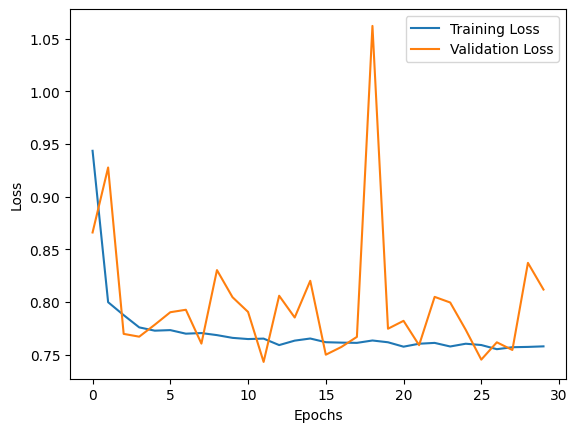

Evaluation:
93/93 [==============================] - 0s 2ms/step - loss: 0.8235 - accuracy: 0.6306
Testing Loss: 0.8235159516334534
Testing Accuracy: 0.6305667757987976
Model 2


Training:
Training Loss: 0.7639285326004028
Training Accuracy: 0.6360653638839722
Validation Loss: 0.775627851486206
Validation Accuracy: 0.6202178001403809


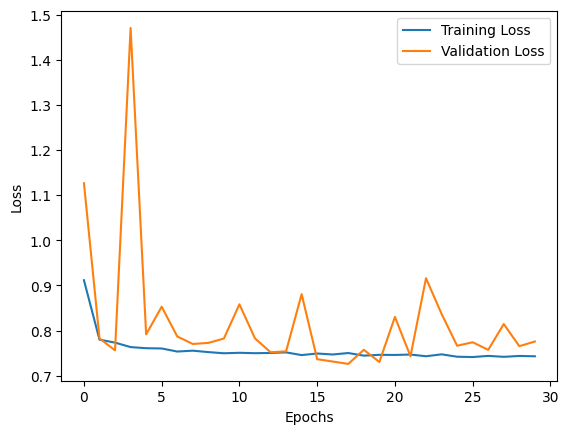

Evaluation:
93/93 [==============================] - 0s 1ms/step - loss: 0.7726 - accuracy: 0.6255


Testing Loss: 0.772648811340332
Testing Accuracy: 0.6255060434341431
Model 3
Training:
Training Loss: 0.7625179886817932
Training Accuracy: 0.6340407729148865
Validation Loss: 0.7726733088493347
Validation Accuracy: 0.6202178001403809


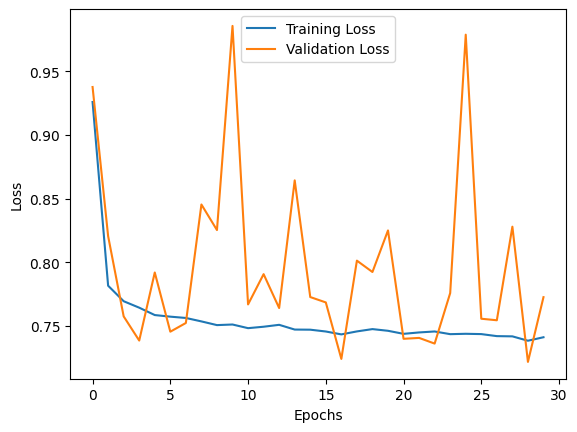

Evaluation:
93/93 [==============================] - 0s 2ms/step - loss: 0.7722 - accuracy: 0.6285


Testing Loss: 0.7721984386444092
Testing Accuracy: 0.6285424828529358
Model 4
Training:
Training Loss: 0.7906141877174377
Training Accuracy: 0.6192404627799988
Validation Loss: 0.7930265069007874
Validation Accuracy: 0.6132365465164185


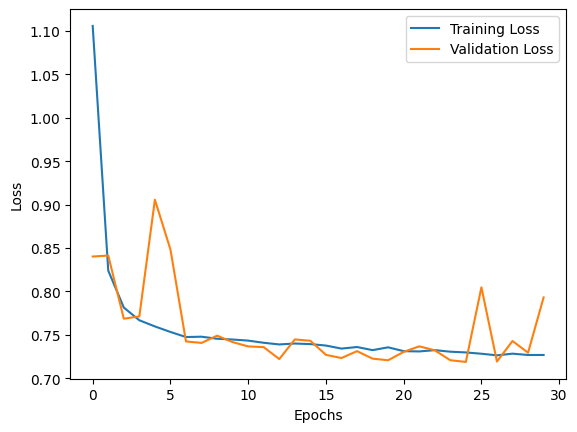

Evaluation:
93/93 [==============================] - 0s 2ms/step - loss: 0.8075 - accuracy: 0.6093
Testing Loss: 0.8074755668640137
Testing Accuracy: 0.6093117594718933
Model 5


Training:
Training Loss: 0.7401055097579956
Training Accuracy: 0.6493996381759644
Validation Loss: 0.7393154501914978
Validation Accuracy: 0.6548449993133545


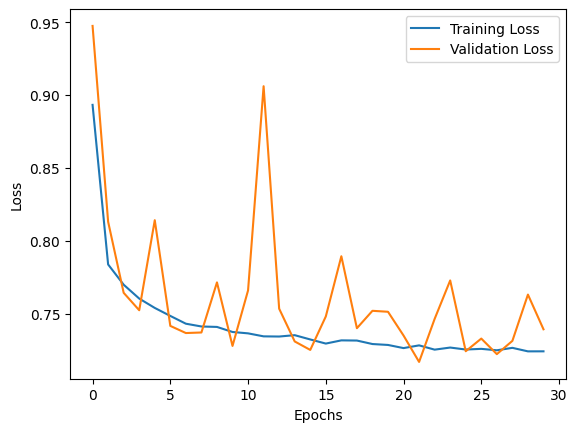

Evaluation:
93/93 [==============================] - 0s 3ms/step - loss: 0.7523 - accuracy: 0.6474
Testing Loss: 0.7523292303085327
Testing Accuracy: 0.6474359035491943


In [ ]:
#     3-31-24       Noah Russell
#Importing our necessary databases
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD

# Load MNIST dataset and split into training and testing sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Filter dataset for only the digits 0, 3, and 8 as instructed
train_filter = np.where((y_train == 0) | (y_train == 3) | (y_train == 8))
test_filter = np.where((y_test == 0) | (y_test == 3) | (y_test == 8))

x_train, y_train = x_train[train_filter], y_train[train_filter]
x_test, y_test = x_test[test_filter], y_test[test_filter]

# Split training data into training and validation sets (Part a)
validation_split = 0.2 # 20% as instructed
split_index = int((1 - validation_split) * len(x_train))

x_val, y_val = x_train[split_index:], y_train[split_index:]
x_train, y_train = x_train[:split_index], y_train[:split_index]

# Setting up Feature extraction: average the pixel values in the quadrants (Part b)
def extract_features(data):
    num_samples = data.shape[0]
    features = np.zeros((num_samples, 4))
    for i in range(num_samples):
        img = data[i]
        features[i][0] = np.mean(img[:14, :14])  # Top left quadrant
        features[i][1] = np.mean(img[:14, 14:])  # Top right quadrant
        features[i][2] = np.mean(img[14:, :14])  # Bottom left quadrant
        features[i][3] = np.mean(img[14:, 14:])  # Bottom right quadrant
    return features
# Saving our train features
x_train_features = extract_features(x_train)
x_val_features = extract_features(x_val)
x_test_features = extract_features(x_test)

# Remap labels to start from 0 and be continuous
label_map = {0: 0, 3: 1, 8: 2}
y_train = np.array([label_map[label] for label in y_train])
y_val = np.array([label_map[label] for label in y_val])
y_test = np.array([label_map[label] for label in y_test])

# Convert labels to binary class matrices using to_categorical (Part c)
num_classes = len(label_map)
y_train = to_categorical(y_train, num_classes)
y_val = to_categorical(y_val, num_classes)
y_test = to_categorical(y_test, num_classes)

# Define function to build, compile, and train the model (Part d i.)
def build_model(num_layers, nodes):
    model = Sequential()
    model.add(Dense(nodes, activation='relu', input_shape=(4,)))
    if num_layers == 2:
        model.add(Dense(16, activation='relu')) #setting nodes to 16
    model.add(Dense(3, activation='softmax'))

    model.compile(optimizer=SGD(lr=0.0001), # Setting learning rate (Part d ii.)
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Define function to train the model and plot the learning curve
def train_model(model, x_train, y_train, x_val, y_val):
    history = model.fit(x_train, y_train, epochs=30, batch_size=16, #Training network for 30 epochs and batch size 16 (Part d iii.)
                        validation_data=(x_val, y_val), verbose=0)

    # Use the evaluate() Keras function to find the training and validation loss and accuracy (Part d v.)
    train_loss, train_accuracy = model.evaluate(x_train, y_train, verbose=0)
    val_loss, val_accuracy = model.evaluate(x_val, y_val, verbose=0)

    # display our results
    print("Training Loss:", train_loss)
    print("Training Accuracy:", train_accuracy)
    print("Validation Loss:", val_loss)
    print("Validation Accuracy:", val_accuracy)

    plt.plot(history.history['loss'], label='Training Loss') # Plot the training loss (i.e., the learning curve) for all the epochs. (Part d iv.)
    plt.plot(history.history['val_loss'], label='Validation Loss') # Plotting validation loss for all epochs
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    return history # so that it doesn't mess up our next epochs

# Evaluate the selected model in part (e) on the testing set and report the testing loss and accuracy. (Part g)
def evaluate_model(model, x_test, y_test):
    loss, accuracy = model.evaluate(x_test, y_test)
    print("Testing Loss:", loss)
    print("Testing Accuracy:", accuracy)

# (Part f) What behavior do you observe in the training loss and the validation loss when you increase the number layers and nodes in the previous table. Which model is more suitable in this problem? Explain.
# From observation, I've noticed that models with more layers and nodes tend to exhibit lower training losses, suggesting better fitting to the training data. However, as the complexity increases beyond a certain point (e.g., Model 4), validation losses start to increase, indicating overfitting. Model 5 (2, 64) appears to be the most suitable for this problem. It achieves the highest accuracy on the testing set while maintaining relatively low training and validation losses, indicating good generalization performance.

# Train and evaluate models (Part e.)
models = [(1, 16), (1, 64), (1, 128), (2, 128), (2, 64)] # our given data in Part e
for i, (num_layers, nodes) in enumerate(models, 1):
    print("Model", i)
    model = build_model(num_layers, nodes)
    print("Training:")
    history = train_model(model, x_train_features, y_train, x_val_features, y_val)
    print("Evaluation:")
    evaluate_model(model, x_test_features, y_test)
